# Gaussian Process regression

This notebook provides a **from-scratch introduction** to **Gaussian Process (GP) regression**.

The notebook starts with the **univariate setting**, introducing covariance kernels, prior distributions over functions, and posterior inference. It then extends naturally to the **multivariate case**, where higher-dimensional inputs and covariance structures are considered.

Along the way, the notebook develops the mathematical foundations of GP regression, including:

- **Kernel functions** and covariance matrices  
- **Posterior mean and covariance derivations**  
- **Predictive uncertainty and confidence intervals**  
- **Sequential updates and active learning** using uncertainty-based acquisition functions  
- Efficient matrix computations, including **rank-one updates** for fast sequential inference  

All implementations are built directly from first principles, with minimal abstraction, to emphasise both the underlying mathematics and the computational structure of Gaussian Process models.

### Univariate Gaussian Process

In this formulation, a zero mean function is assumed for the Gaussian Process prior, which reflects a non-informative baseline over functions before observing any data.

To demonstrate the GP’s predictive capability, a strongly fluctuating univariate function is used,
$$
f(x) = e^{-x^2}\sin(5x) + \frac{\log(1+x^2)}{1+x^4} + (x^2 + \cos(3x) + 1.1)^{1/3},
$$


A simple maximum variance acquisition function is used, where the next point is selected as $x_{\text{next}} = \arg\max_x \text{Var}[f(x)]$, prioritising regions of greatest uncertainty.

In [19]:
import numpy as np
import jax.numpy as jnp

# Nonlinear target function
def f(x):
    return (
        jnp.exp(-x**2) * jnp.sin(5*x)
        + jnp.log(1 + x**2) / (1 + x**4)
        + (x**2 + jnp.cos(3*x) + 1.1)**(1/3)
    )

# Domain boundaries
lower = -2.0
upper = 2.0

# Total number of sequential observations
n_total = 12

# Dense evaluation grid for plotting
x_eval = np.linspace(lower, upper, 250)

# Containers for observed data
x_data = jnp.array([])
y_data = jnp.array([])

## Gaussian Process Regression Theory

Gaussian Process regression follows directly from the conditioning properties of a **multivariate Gaussian distribution**.

Consider the partitioned Gaussian vector

$$
\begin{bmatrix} \mathbf{x}_1 \\ \mathbf{x}_2 \end{bmatrix}
\sim
\mathcal{N}\left(
\begin{bmatrix} \boldsymbol{\mu}_1 \\ \boldsymbol{\mu}_2 \end{bmatrix},
\begin{bmatrix}
\Sigma_{11} & \Sigma_{12} \\
\Sigma_{21} & \Sigma_{22}
\end{bmatrix}
\right).
$$

Conditioning $\mathbf{x}_2$ on $\mathbf{x}_1$ gives the conditional mean and covariance

$$
\boldsymbol{\mu}_{2|1}
=
\boldsymbol{\mu}_2
+
\Sigma_{21}\Sigma_{11}^{-1}
(\mathbf{x}_1-\boldsymbol{\mu}_1),
$$

$$
\Sigma_{2|1}
=
\Sigma_{22}
-
\Sigma_{21}\Sigma_{11}^{-1}\Sigma_{12}.
$$

In Gaussian Process regression, we interpret these variables as function values:

$$
\mathbf{x}_1 = \mathbf{f},
\qquad
\mathbf{x}_2 = \mathbf{f}_*,
\qquad
\boldsymbol{\mu}_1 = \mathbf{0},
\qquad
\boldsymbol{\mu}_2 = \mathbf{0},
$$

with covariance matrices defined through a kernel function:

$$
\Sigma_{11}=K(X,X),
\qquad
\Sigma_{12}=K(X,X_*),
$$

$$
\Sigma_{21}=K(X_*,X),
\qquad
\Sigma_{22}=K(X_*,X_*).
$$

This gives the joint Gaussian prior

$$
p\left(
\begin{bmatrix}
\mathbf{f} \\
\mathbf{f}_*
\end{bmatrix}
\middle| X, X_*
\right)
=
\mathcal{N}
\left(
\begin{bmatrix}
\mathbf{0} \\
\mathbf{0}
\end{bmatrix},
\begin{bmatrix}
K(X,X) & K(X,X_*) \\
K(X_*,X) & K(X_*,X_*)
\end{bmatrix}
\right).
$$

The resulting GP posterior **mean** is

$$
\begin{aligned}
\boldsymbol{\mu}_{\mathbf{f}_*|\mathbf{f}}
&=
\boldsymbol{\mu}_2
+
\Sigma_{21}\Sigma_{11}^{-1}
(\mathbf{x}_1-\boldsymbol{\mu}_1)
\\
&=
K(X_*,X)\,
K(X,X)^{-1}\mathbf{f}.
\end{aligned}
$$

The posterior **covariance** is

$$
\begin{aligned}
\Sigma_{\mathbf{f}_*|\mathbf{f}}
&=
\Sigma_{22}
-
\Sigma_{21}\Sigma_{11}^{-1}\Sigma_{12}
\\
&=
K(X_*,X_*)
-
K(X_*,X)\,
K(X,X)^{-1}\,
K(X,X_*).
\end{aligned}
$$

These expressions form the foundation of Gaussian Process regression, defining both the predictive mean and the associated uncertainty over unseen inputs.

---

### Sequential Gaussian Process Regression 

This cell implements a **sequential Gaussian Process regression** scheme driven by **predictive uncertainty**.

Starting from a single random observation, a GP model is fitted using fixed hyperparameters. At each iteration, the model computes the posterior mean and variance over a fixed evaluation grid, and selects a new input at the location of **maximum uncertainty**, i.e.

$$
A(x)=\arg\max_x \operatorname{Var}(X).
$$

Each step produces a visualisation of the GP fit, including the **posterior mean**, the observed data, and a **95% confidence interval** around the prediction.

To maintain efficiency, the kernel inverse is updated using a **rank-one update**, avoiding full recomputation of the covariance matrix at each iteration.

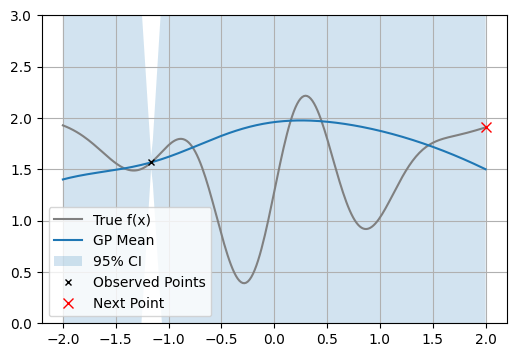

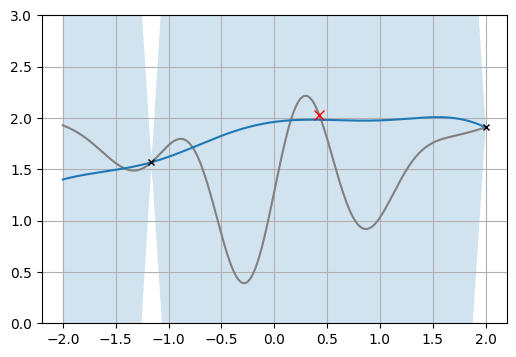

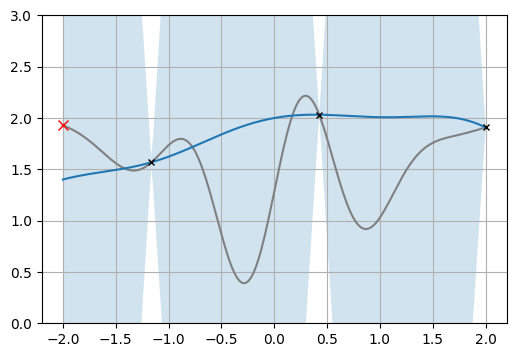

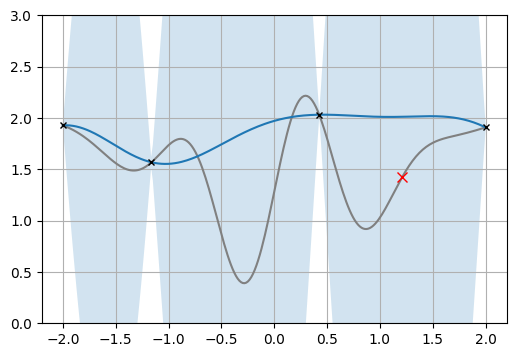

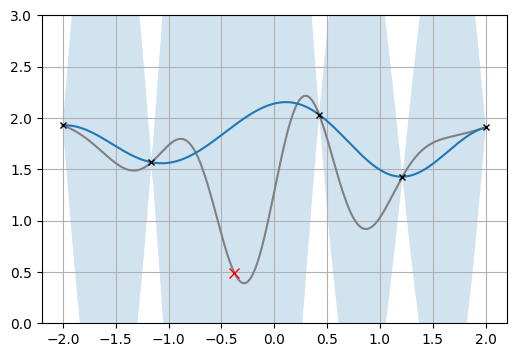

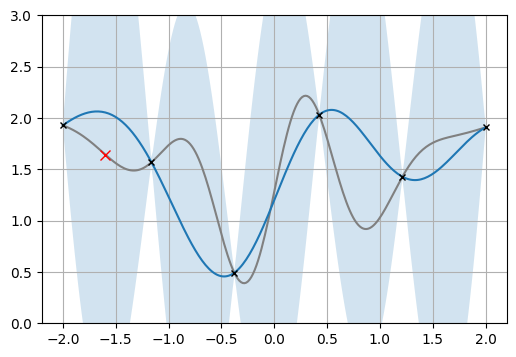

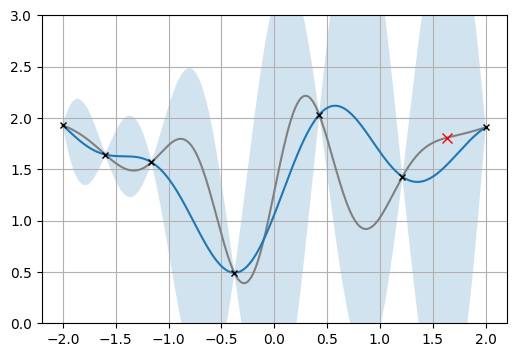

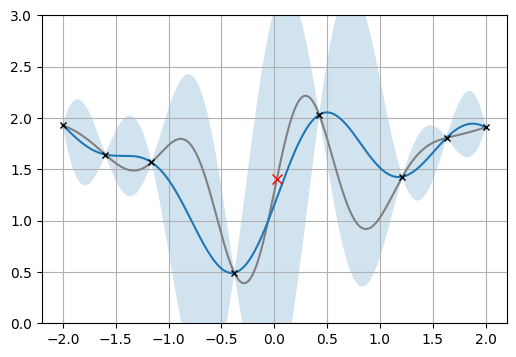

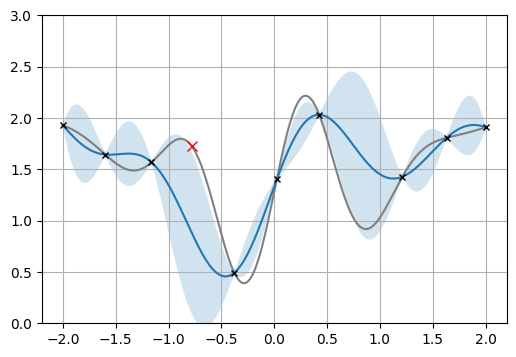

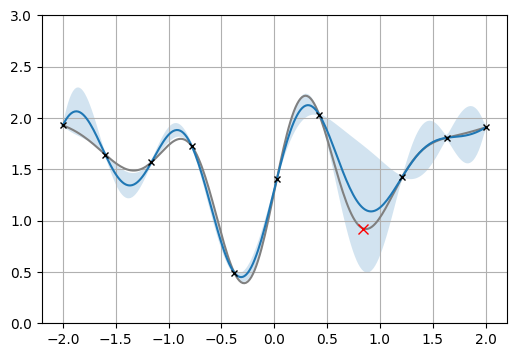

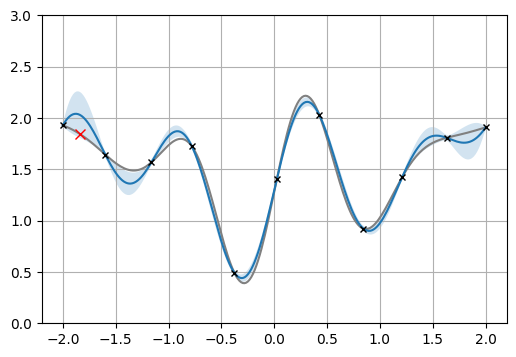

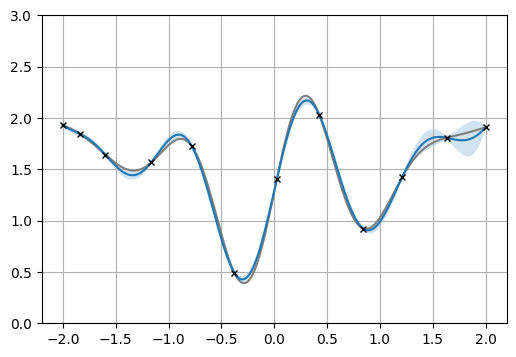

In [20]:
import matplotlib.pyplot as plt
from gp_utils import kinv, reshape, gp_predict, rank_one_update

# Initial random observation
x1 = jnp.array(np.random.uniform(lower, upper))
x_data = jnp.append(x_data, x1)
y_data = jnp.append(y_data, f(x1))

# GP hyperparameters
L = jnp.array([0.6])

s, L, m0, x_m, w = (
    jnp.array([5]),
    jnp.diag(L),
    jnp.array([2]),
    jnp.array([0]),
    2
)

hp_sample = (s, L, m0, x_m, w, 0.0)

# Initial covariance inverse
chol_k1, kxx_inv = kinv(
    jnp.atleast_1d(x1),
    hp_sample
)

# Sequential GP fitting
for i in range(n_total):

    # Reshape training data
    x, y = reshape(x_data, y_data)

    # GP posterior prediction
    mu_eval, var_eval = gp_predict(
        x, y, x_eval,
        s=s,
        L=jnp.diag(L),
        m0=m0,
        x_m=x_m,
        w=w,
        K_inv=kxx_inv
    )

    # Predictive standard deviation
    sig_diag = jnp.sqrt(jnp.diag(var_eval[0]))

    # Choose next point using maximum uncertainty
    if i < n_total - 1:
        x_next = x_eval[
            jnp.argmax(jnp.diag(var_eval[0]))
        ]
        y_next = f(x_next)
    else:
        x_next = None

    # Plot current GP fit
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(
        x_eval,
        f(x_eval),
        color='gray',
        label='True f(x)'
    )

    ax.plot(
        x_eval,
        mu_eval,
        label='GP Mean'
    )

    ax.fill_between(
        x_eval,
        mu_eval - 1.96 * sig_diag,
        mu_eval + 1.96 * sig_diag,
        alpha=0.2,
        label='95% CI'
    )

    ax.plot(
        x_data,
        y_data,
        'x',
        color='black',
        label='Observed Points',
        markersize=5
    )

    # Highlight next selected point
    if x_next is not None:
        ax.plot(
            x_next,
            y_next,
            'x',
            color='red',
            label='Next Point',
            markersize=7
        )

    ax.set_ylim(0, 3)
    ax.grid()
    if i ==0:
        ax.legend()

    plt.show()

    # Update dataset and covariance inverse
    if i < n_total - 1:

        x_data = jnp.append(x_data, x_next)
        y_data = jnp.append(y_data, y_next)

        x, y = reshape(x_data, y_data)

        kxx_inv = rank_one_update(
            x,
            kxx_inv,
            hp_sample
        )

### Bivariate Gaussian Process

To demonstrate the behaviour of Gaussian Process regression in two dimensions, a smooth bivariate function is considered, defined through a radial transformation

$$
r = 0.4\sqrt{x^2 + xy + y^2},
\qquad
g(x,y) = \sin^2(r).
$$

A structured training set is constructed by discretising the input space using a uniform grid via `linspace` and `meshgrid`, producing evenly spaced observations over the domain. This provides full coverage of the surface without relying on adaptive sampling or uncertainty-based selection.

The GP is then fitted on this training data using fixed hyperparameters, and predictions are evaluated over a finer grid to obtain a smooth approximation of the underlying surface. The resulting posterior mean is reshaped into a 2D field for visualisation.

To assess predictive performance, a single random test point is drawn from the domain. The true function value at this point is computed and compared against the GP prediction, together with the associated uncertainty estimate and 95% confidence interval.

Finally, the learned GP surface is visualised in three dimensions, allowing direct comparison between the reconstructed function and the true underlying structure.

At X: 3.509 and Y: -7.093
--------------------------------------
The function value is: 0.3997
The gp estimate is:    0.3905
Error:                 0.0091
The gp std is:         0.0163
95% CI: [0.3586, 0.4224]



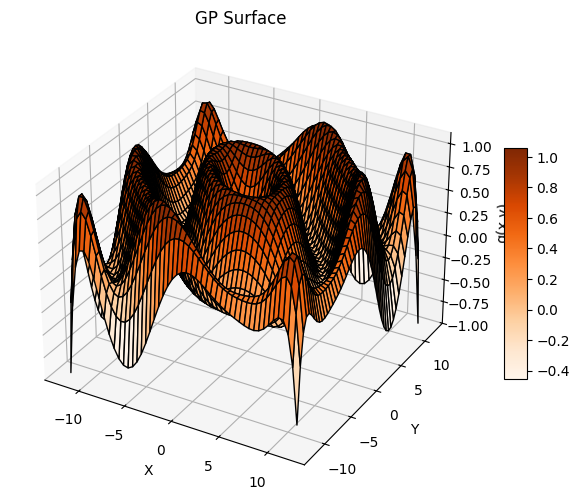

In [26]:
# Example function g(x,y)
def g(x, y):
    r = 0.4*jnp.sqrt(x**2 + x*y + y**2)
    return jnp.sin(r)**2

#training data
x = jnp.linspace(-11, 11, 11)
y = jnp.linspace(-11, 11, 11)
X, Y = jnp.meshgrid(x, y)
xy = jnp.column_stack([X.ravel(), Y.ravel()])
gxy1 = g(xy[:, 0], xy[:, 1])


#evaluation points
x = np.linspace(-12, 12, 50)
y = np.linspace(-12, 12, 50)
X_eval, Y_eval = np.meshgrid(x, y)
xy_eval = np.column_stack([X_eval.ravel(), Y_eval.ravel()])

s = 6
L = jnp.array([4,4])

s, L, m0, x_m, w = jnp.array([s]), [L], jnp.array([2]),jnp.array([0,0]), jnp.array([2,2])
hp_sample = (s,L,m0,x_m,w,0.0)

x,y = reshape(xy,gxy1)
chol_k1, kxx_inv = kinv(xy,hp_sample)
mu_grid, var_eval = gp_predict(
        x, y, xy_eval,
        s=s,L=jnp.diag(L[0]),
        m0=m0,x_m=x_m,w=w,
        K_inv=kxx_inv)
mu_grid = mu_grid.reshape(X_eval.shape)


#calculate function value at random point
x1_test = np.random.uniform(-11, 11, 1)[0]
x2_test = np.random.uniform(-11, 11, 1)[0]
x_test = jnp.array([[x1_test, x2_test]])
y_test = g(x1_test, x2_test)


#predict at same random point
gp_est, gp_var = gp_predict(
    x, y, x_test,
    s=s,L=jnp.diag(L[0]),
    m0=m0,x_m=x_m,w=w,
    K_inv=kxx_inv)
gp_var = gp_var[0]
low = gp_est - 1.96*jnp.sqrt(gp_var)
high = gp_est + 1.96*jnp.sqrt(gp_var)
error = np.abs(y_test - gp_est)


print(f'At X: {x1_test:.3f} and Y: {x2_test:.3f}')
print('--------------------------------------')
print(f'The function value is: {y_test:.4f}')
print(f'The gp estimate is:    {gp_est[0]:.4f}')
print(f'Error:                 {error[0]:.4f}')
print(f'The gp std is:         {jnp.sqrt(gp_var[0][0]):.4f}')
print(f'95% CI: [{low[0][0]:.4f}, {high[0][0]:.4f}]')
print()


# Plot GP surface and product surface side by side
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_eval, Y_eval, mu_grid, cmap="Oranges", edgecolor='k')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('g(x,y)')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
ax1.set_title(f'GP Surface')
plt.show()

### Trivariate Gaussian Process

To demonstrate the Gaussian Process’s capability in modelling smooth three-dimensional functions, the following trivariate function is utilised,
which depends on the radial distance $r = 0.3\sqrt{x^2 + xy + xz + yz + y^2 + z^2}$:

$$
g(x, y, z) = \sin^2(3r) = \sin^2\left(3 \times 0.3\sqrt{x^2 + xy + xz + yz + y^2 + z^2}\right).
$$

A regular grid-based sampling approach is employed here, where the three-dimensional input space is discretised using evenly spaced points generated via `linspace` and `meshgrid`.
This ensures uniform coverage of the domain, providing a consistent basis for visualising and testing the Gaussian Process’s trivariate predictions.


In [27]:
def g3(x, y, z):
    r = 0.3*np.sqrt(x**2 + x*y + x*z + y*z + y**2 + z**2)
    return np.sin(3*r)**2
    

#training data
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
z = np.linspace(-5, 5, 10)
X, Y, Z = np.meshgrid(x, y, z)
xyz = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
gxyz = g3(*xyz.T)

s = 6
L = jnp.array([2,2,2])

s, L, m0, x_m, w = jnp.array([s]), [L], jnp.array([2]),jnp.array([0,0,0]), jnp.array([2,2,2])
hp_sample = (s,L,m0,x_m,w,0.0)

x,y = reshape(xyz,gxyz)
chol_k1, kxx_inv = kinv(xyz,hp_sample)


#predict at same random point
x1_test = np.random.uniform(-5, 5, 1)[0]
x2_test = np.random.uniform(-5, 5, 1)[0]
x3_test = np.random.uniform(-5, 5, 1)[0]
x_test = jnp.array([[x1_test, x2_test,x3_test]])
y_test = g3(x1_test,x2_test,x3_test)

gp_est, gp_var = gp_predict(
    x, y, x_test,
    s=s,L=jnp.diag(L[0]),
    m0=m0,x_m=x_m,w=w,
    K_inv=kxx_inv)
gp_var = gp_var[0]
low = gp_est - 1.96*jnp.sqrt(gp_var)
high = gp_est + 1.96*jnp.sqrt(gp_var)
error = np.abs(y_test - gp_est)


print('--------------------------------------')
print(f'The function value is: {y_test:.4f}')
print(f'The gp estimate is:    {gp_est[0]:.4f}')
print(f'Error:                 {error[0]:.4f}')
print(f'The gp std is:         {jnp.sqrt(gp_var[0][0]):.4f}')
print(f'95% CI: [{low[0][0]:.4f}, {high[0][0]:.4f}]')
print()


--------------------------------------
The function value is: 0.4378
The gp estimate is:    0.4436
Error:                 0.0058
The gp std is:         0.0236
95% CI: [0.3973, 0.4899]



In this notebook we used a **zero mean prior**, but a **negative quadratic mean function** will be used in the coming quadrature and VBMC notebooks. The relevant results are derived in **Section 4 of `derivations.ipynb`**.